In [1]:
from model import train, GPT2Model
import torch
from torch import nn
from matplotlib import pyplot as plt
from pt_5_pretraining_on_unlabeled_data.funcs_and_classes import *

In [2]:
EPOCHS = 40
LR = 0.0004
GAMMA = 0.1
NUM_SCHEDULING = 7
MAX_NEW_TOKENS = 100
sample_text = "Please make me a"
WEIGHT_DECAY = 0.1
TEMP = 1.4
TOP_K = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GPT_CONFIG = {
        "vocab_size": 50257,
        "context_length": 256,
        "emb_dim": 768,
        "n_heads": 12,
        "n_layers": 12,
        "drop_rate": 0.1,
        "qkv_bias": False
    }

torch.manual_seed(42); torch.cuda.manual_seed(42)
model = GPT2Model(GPT_CONFIG).to(DEVICE)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(params=model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, NUM_SCHEDULING, gamma=GAMMA)

In [3]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    text_data = f.read()

train_ratio = 0.9
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

torch.manual_seed(42); torch.cuda.manual_seed(42)
train_loader = create_dataloader_v1(
    txt=train_data,
    batch_size=4,
    max_length=GPT_CONFIG["context_length"],
    stride=GPT_CONFIG["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=4
)

val_loader = create_dataloader_v1(
    txt=val_data,
    batch_size=4,
    max_length=GPT_CONFIG["context_length"],
    stride=GPT_CONFIG["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=4
)

tokenizer = tiktoken.get_encoding("gpt2")


Epoch: 1 | Train loss: 9.82358694076538 | Val loss: 8.784438133239746
Text generation test: 
Please make me a, I



 the the,, and the the-- a, the of the, the the the the,,



 in the a.












,


, of that to,,












 the the. the
",,.,, of,, had I to the.

,




.
 of

Epoch: 2 | Train loss: 7.925837397575378 | Val loss: 7.527955532073975
Text generation test: 
Please make me a the.





" to I
" of and-- one to I and to my, and in, with.






" the it was of was had to in the had the.


































".






" he, had-- and he I

Epoch: 3 | Train loss: 6.57854700088501 | Val loss: 8.300174713134766
Text generation test: 
Please make me a She"I was just
"


"""'t"
""I and"
"




" of the.

"'t"

" house.
".
"

"--"
" to was of the


"" was that that, he was--""""
"


"
" and in the".

""

" of the of the donkey"

Epoch: 4 | Train loss: 5.933805227279663 | Val loss: 6.482424736022949
Text generation test: 
Please make me a a
 and he his, in the. it my

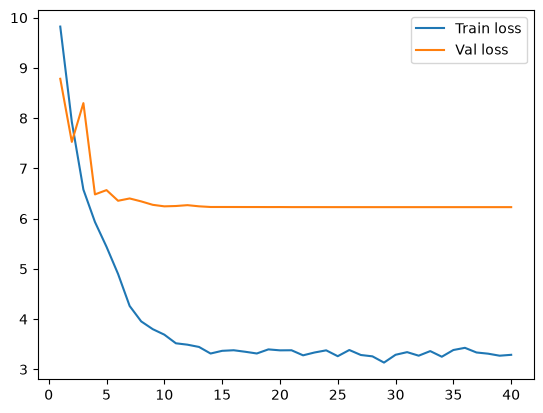

In [4]:
model, train_losses, val_losses, epochs = train(
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    device=DEVICE,
    EPOCHS=EPOCHS,
    tokenizer=tokenizer,
    sample_text=sample_text,
    max_new_tokens=MAX_NEW_TOKENS,
    temp=TEMP,
    top_k=TOP_K
)

plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, val_losses, label="Val loss")
plt.legend()
plt.show()

In [5]:
torch.save(model.state_dict(), "model.pth")